# VET Data

**Importing Package**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Sheets**

In [2]:
# Load Excel file
file_path = 'VET_Data_task1.xlsx'
xls = pd.ExcelFile(file_path)
print("Available Sheets:", xls.sheet_names)

Available Sheets: ['Tasks', 'Data Dictionary', 'Organisation', 'Contract', 'Student', 'Enrolment']


In [3]:
# Load individual sheets based on the Data Dictionary
organisation_df = pd.read_excel(xls, sheet_name='Organisation')
contract_df = pd.read_excel(xls, sheet_name='Contract')
student_df = pd.read_excel(xls, sheet_name='Student')
enrolment_df = pd.read_excel(xls, sheet_name='Enrolment')

In [4]:
# Display basic info and first few rows
display(student_df.head(10))

,Student_ID,USI,Gender,DOB,ATSI,At_School_Flag
0,STU93810,C2WQP5CYGD,F,1967-01-24,Y,N
1,STU81426,S9Z2Y3SE4Q,X,1986-04-15,Y,N
2,STU44671,SMF73WN4TQ,Male,1962-12-15,Y,N
3,STU40512,QHCT6C54JW,F,1966-07-09,N,N
4,STU93886,F2YMC9Q6X2,X,2004-09-08,Y,N
5,STU94259,2GMQRBTEZX,M,1989-03-09,Y,N
6,STU92240,7ZM8PL6MCR,X,1970-11-14,Y,N
7,STU24621,3GQEXRLHUX,F,1978-07-06,Y,N
8,STU31174,8PF4WYDK24,X,1994-09-01,Y,Y
9,STU79822,P34N6KHXWE,F,1968-03-22,N,N


**Data Cleaning**

In [5]:
# Convert all columns to lowercase
student_df.columns = student_df.columns.str.lower()

In [6]:
# Check data types and non-null counts
student_df.info()

# Check for missing values per column
print("\nMissing Values:")
print(student_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   student_id      1974 non-null   object        
 1   usi             1974 non-null   object        
 2   gender          1974 non-null   object        
 3   dob             1974 non-null   datetime64[ns]
 4   atsi            1974 non-null   object        
 5   at_school_flag  1974 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 92.7+ KB

Missing Values:
student_id        0
usi               0
gender            0
dob               0
atsi              0
at_school_flag    0
dtype: int64


In [7]:
# Checking duplicates
exact_dupes_count = student_df.duplicated().sum()
print("Exact duplicate rows:", exact_dupes_count)

# Remove duplicates if any exist
if exact_dupes_count > 0:
    student_df = student_df.drop_duplicates().reset_index(drop=True)
    print("Total rows after removing duplicates:", len(student_df))

Exact duplicate rows: 0


In [8]:
# Clean and convert the gender column values
student_df['gender'] = student_df['gender'].astype(str).str.strip().str.lower()

# Map the values as requested
gender_mapping = {
    'male': 'm',
    'female': 'f',
    'x': 'Not Specified'
}

# Apply the mapping
student_df['gender'] = student_df['gender'].map(gender_mapping).fillna(student_df['gender'])

# Verify the updated gender counts
print(student_df['gender'].value_counts())

gender
f                670
Not Specified    657
m                647
Name: count, dtype: int64


In [9]:
display(student_df)

,student_id,usi,gender,dob,atsi,at_school_flag
0,STU93810,C2WQP5CYGD,f,1967-01-24,Y,N
1,STU81426,S9Z2Y3SE4Q,Not Specified,1986-04-15,Y,N
2,STU44671,SMF73WN4TQ,m,1962-12-15,Y,N
3,STU40512,QHCT6C54JW,f,1966-07-09,N,N
4,STU93886,F2YMC9Q6X2,Not Specified,2004-09-08,Y,N
...,...,...,...,...,...,...
1969,STU99394,UT94RNNNAB,m,1988-10-07,N,N
1970,STU75661,2JPYVM2FRD,Not Specified,1984-08-28,Y,N
1971,STU65613,TD8XHVMSFS,f,2008-06-20,N,N
1972,STU92360,DEUSKBP7YB,f,2007-04-09,N,N


**Exploratory Data Analysis (EDA)**

In [10]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [11]:
print(student_df.columns.tolist())

['student_id', 'usi', 'gender', 'dob', 'atsi', 'at_school_flag']


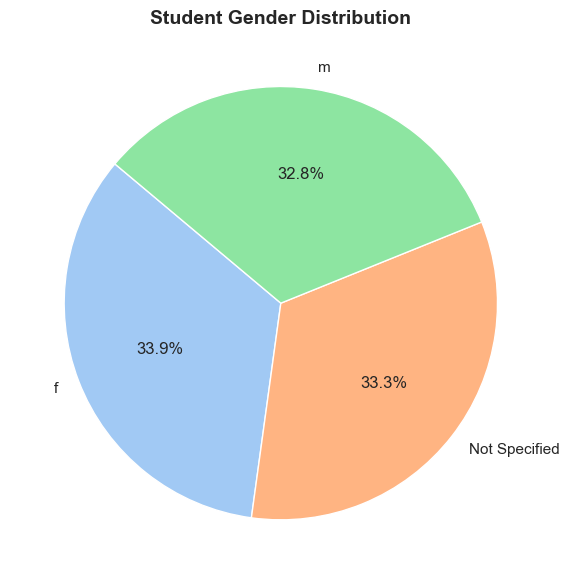

In [12]:
plt.figure(figsize=(6, 6))
gender_counts = student_df['gender'].value_counts()

plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Student Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

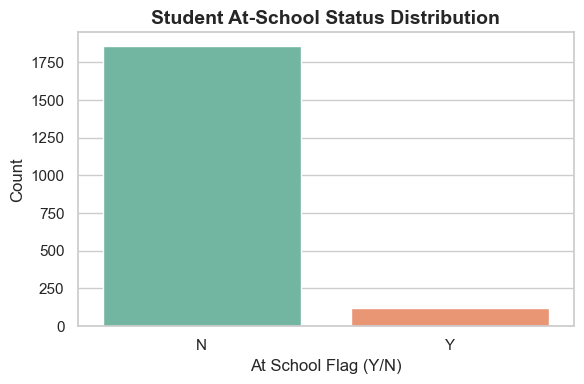

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=student_df, 
    x='at_school_flag', 
    hue='at_school_flag', 
    legend=False,
    palette='Set2'
)

plt.title('Student At-School Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('At School Flag (Y/N)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

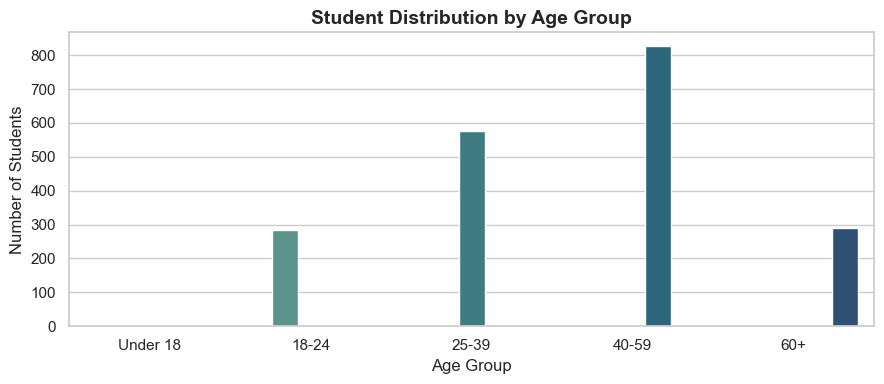

In [14]:
# Convert DOB to datetime and calculate age (using current year 2026)
student_df['dob'] = pd.to_datetime(student_df['dob'], errors='coerce')
student_df['age'] = 2026 - student_df['dob'].dt.year

# Define age bins and labels
bins = [0, 18, 25, 40, 60, 100]
labels = ['Under 18', '18-24', '25-39', '40-59', '60+']
student_df['age_group'] = pd.cut(student_df['age'], bins=bins, labels=labels, right=False)

# Plot age group distribution
plt.figure(figsize=(9, 4))
sns.countplot(
    data=student_df, 
    x='age_group', 
    hue='age_group', 
    legend=False,
    order=labels, 
    palette='crest'
)

plt.title('Student Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.tight_layout()
plt.show()